# Clock Model: Temperature Sweep and Discrete Symmetry Breaking

The $q$-state clock model restricts the continuous XY angle to $q$ equally spaced orientations $\theta_k = 2\pi k/q$, with the Hamiltonian $H = -J \sum_{\langle i,j \rangle} \cos(\theta_i - \theta_j) - A \sum_i \cos(q\,\theta_i)$, where $A$ is a crystal-field anisotropy strength that favours the discrete directions. For $q = 2$ the model reduces to the Ising model, while in the limit $q \to \infty$ it recovers the XY model. The intermediate case $q = 6$ (the default used here) displays rich phase structure: for sufficiently large $q$ the system undergoes two Berezinskii-Kosterlitz-Thouless-type crossovers rather than a single sharp phase transition. The lower transition is a discrete locking transition at which spins select among the $q$ preferred axes, and the upper transition is a vortex-unbinding crossover analogous to the XY BKT transition [[1]](#Bibliography) [[2]](#Bibliography).

This notebook presents a thermodynamic temperature sweep that records magnetization, energy, susceptibility, specific heat, entropy, and integrated autocorrelation time across these regimes. The high-temperature entropy reference for the clock model is $S_{\mathrm{ref}} = \ln q$ per site, reflecting equipartition over the $q$ allowed orientations [[2]](#Bibliography).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from models.clock_model import ClockSimulation
from utils.exceptions import ZeroVarianceAutocorrelationError
from utils.statistics import (
    DEFAULT_CONFIDENCE_LEVEL,
    calculate_autocorr,
    summarize_derived_observable,
    summarize_entropy_observable,
    summarize_primary_observable,
)
from utils.equilibration import (
    convergence_equilibrate,
    estimate_relaxation_time_two_start,
    _detect_quasi_steady_stuck,
)


def _find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'results').exists():
            return candidate
    return cwd


REPO_ROOT = _find_repo_root()
Q_DEFAULT = 6
S_REF = np.log(Q_DEFAULT)
CACHE_PATH = REPO_ROOT / 'results' / 'clock' / 'temperature_sweep_data.npz'
PALETTE = {
    'mag': '#4878CF',
    'eng': '#6ACC65',
    'chi': '#EE854A',
    'cv': '#D65F5F',
    'entropy': '#956CB4',
    'tau': '#8C613C',
}

plt.rcParams['figure.dpi'] = 120

print(f'Clock states q = {Q_DEFAULT}')
print(f'High-T entropy reference S_ref = ln({Q_DEFAULT}) = {S_REF:.4f}')
print(f'Repository root: {REPO_ROOT}')
print(f'Primary sweep path: {CACHE_PATH}')

Clock states q = 6
High-T entropy reference S_ref = ln(6) = 1.7918
Repository root: /workspaces/vibespin
Primary sweep path: /workspaces/vibespin/results/clock/temperature_sweep_data.npz


## Ordered and Disordered Configurations

Below the lower transition, all spins lock to a single preferred axis and the snapshot is nearly uniform in color. Between the two transitions the system exhibits quasi-long-range order with slowly varying patches (similar to the XY quasi-ordered phase). Above the upper transition the field becomes short-range correlated and the angle distribution fills all $q$ states. The snapshots below use an HSV colormap on the local angle $\theta_i$ after equilibration with checkerboard Metropolis updates on a $48 \times 48$ lattice.

convergence_equilibrate: detected quasi-steady stuck state before max_steps=6000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=6000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=6000; stopping early without convergence.


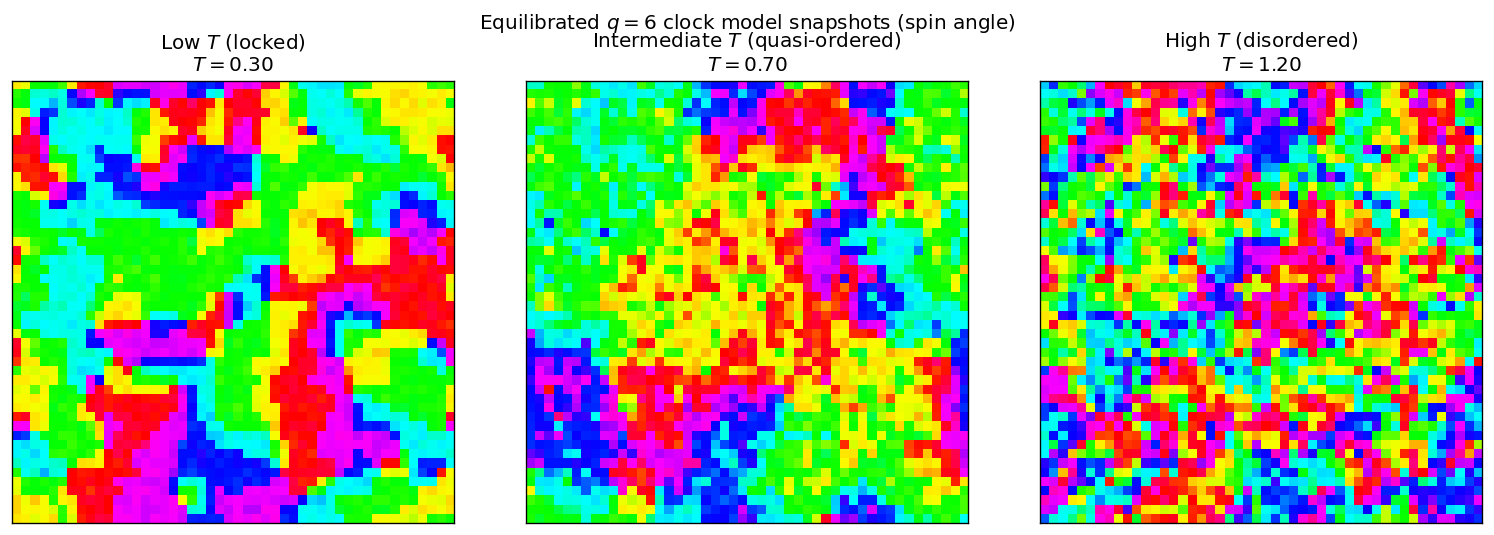

In [2]:
def _equilibrated_state(*, temp: float, size: int = 48, seed: int = 0) -> np.ndarray:
    sim_random = ClockSimulation(
        size=size,
        temp=temp,
        q=Q_DEFAULT,
        update='checkerboard',
        init_state='random',
        seed=seed,
    )
    sim_ordered = ClockSimulation(
        size=size,
        temp=temp,
        q=Q_DEFAULT,
        update='checkerboard',
        init_state='ordered',
        seed=seed,
    )
    convergence_equilibrate(
        sim_random,
        sim_ordered,
        chunk_size=120,
        max_steps=6000,
    )
    sim_random.run(n_steps=200)
    return np.array(sim_random.spins, copy=True)

snapshot_temperatures = [0.3, 0.7, 1.2]
snapshot_titles = ['Low $T$ (locked)', 'Intermediate $T$ (quasi-ordered)', 'High $T$ (disordered)']
snapshot_states = [
    _equilibrated_state(temp=float(temp), seed=300 + idx)
    for idx, temp in enumerate(snapshot_temperatures)
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, spins, title, temp in zip(axes, snapshot_states, snapshot_titles, snapshot_temperatures):
    angles = np.arctan2(spins[:, :, 1], spins[:, :, 0])
    ax.imshow(angles, cmap='hsv', vmin=-np.pi, vmax=np.pi, interpolation='nearest')
    ax.set_title(f'{title}\n$T = {temp:.2f}$')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'Equilibrated $q = {Q_DEFAULT}$ clock model snapshots (spin angle)', y=0.98)
fig.tight_layout()
plt.show()

## Load or Compute Sweep Data

The notebook first checks for precomputed data at `results/clock/temperature_sweep_data.npz` (produced by `scripts/clock/temperature_sweep.py`). If the cache contains a sufficiently dense temperature grid with all required uncertainty fields, plots are built directly from those arrays. Otherwise a lightweight fallback sweep runs inline on a small lattice with reduced measurement steps. The fallback results are noisier but show the qualitative shape of each observable curve across the two crossover regions.

In [3]:
REQUIRED_KEYS = {
    'temperatures',
    'avg_m_value', 'avg_m_ci_low', 'avg_m_ci_high', 'avg_m_n_eff',
    'avg_e_value', 'avg_e_ci_low', 'avg_e_ci_high',
    'susc_value', 'susc_ci_low', 'susc_ci_high',
    'spec_h_value', 'spec_h_err', 'spec_h_ci_low', 'spec_h_ci_high',
    'tau_int',
    'undefined_autocorr_flag', 'tau_interval_unstable_flag',
}

fallback_meas_steps = 1200


def _run_local_sweep_point(
    *,
    temp: float,
    size: int,
    meas_steps: int,
    eq_probe_steps: int,
    eq_max_steps: int,
    seed: int,
) -> dict[str, float]:
    sim_random = ClockSimulation(
        size=size,
        temp=temp,
        q=Q_DEFAULT,
        update='checkerboard',
        init_state='random',
        seed=seed,
    )
    sim_ordered = ClockSimulation(
        size=size,
        temp=temp,
        q=Q_DEFAULT,
        update='checkerboard',
        init_state='ordered',
        seed=seed,
    )
    convergence_equilibrate(
        sim_random,
        sim_ordered,
        chunk_size=eq_probe_steps,
        max_steps=eq_max_steps,
    )

    mags, engs = sim_random.run(n_steps=meas_steps)
    mags_arr = np.asarray(mags, dtype=float)
    engs_arr = np.asarray(engs, dtype=float)

    mag = summarize_primary_observable(
        time_series=mags_arr,
        confidence=DEFAULT_CONFIDENCE_LEVEL,
    )
    eng = summarize_primary_observable(
        time_series=engs_arr,
        confidence=DEFAULT_CONFIDENCE_LEVEL,
    )
    chi = summarize_derived_observable(
        magnetization_series=mags_arr,
        temperature=temp,
        L=size,
        observable='chi',
        confidence=DEFAULT_CONFIDENCE_LEVEL,
    )
    cv = summarize_derived_observable(
        energy_series=engs_arr,
        temperature=temp,
        L=size,
        observable='cv',
        confidence=DEFAULT_CONFIDENCE_LEVEL,
    )

    return {
        'avg_m_value': float(mag['value']),
        'avg_m_ci_low': float(mag['ci_low']),
        'avg_m_ci_high': float(mag['ci_high']),
        'avg_m_n_eff': float(mag['n_eff']),
        'avg_e_value': float(eng['value']),
        'avg_e_ci_low': float(eng['ci_low']),
        'avg_e_ci_high': float(eng['ci_high']),
        'susc_value': float(chi['value']),
        'susc_ci_low': float(chi['ci_low']),
        'susc_ci_high': float(chi['ci_high']),
        'spec_h_value': float(cv['value']),
        'spec_h_err': float(cv['err']),
        'spec_h_ci_low': float(cv['ci_low']),
        'spec_h_ci_high': float(cv['ci_high']),
        'tau_int': float(mag['tau_int']),
        'tau_int_ci_low': float(mag['ci_low']) if not np.isfinite(mag['tau_int']) else float(max(0.0, mag['tau_int'] - mag['err'])),
        'tau_int_ci_high': float(mag['ci_high']) if not np.isfinite(mag['tau_int']) else float(mag['tau_int'] + mag['err']),
    }


cache_loaded = False
cache_reason = ''
requested_n_seeds = 1
retained_n_seeds = 1

if CACHE_PATH.exists():
    cache = np.load(CACHE_PATH)
    if REQUIRED_KEYS.issubset(set(cache.files)) and int(cache['temperatures'].size) >= 10:
        temperatures = np.asarray(cache['temperatures'], dtype=float)
        avg_m = np.asarray(cache['avg_m_value'], dtype=float)
        avg_m_ci_low = np.asarray(cache['avg_m_ci_low'], dtype=float)
        avg_m_ci_high = np.asarray(cache['avg_m_ci_high'], dtype=float)
        avg_m_n_eff = np.asarray(cache['avg_m_n_eff'], dtype=float)
        avg_e = np.asarray(cache['avg_e_value'], dtype=float)
        avg_e_ci_low = np.asarray(cache['avg_e_ci_low'], dtype=float)
        avg_e_ci_high = np.asarray(cache['avg_e_ci_high'], dtype=float)
        susc = np.asarray(cache['susc_value'], dtype=float)
        susc_ci_low = np.asarray(cache['susc_ci_low'], dtype=float)
        susc_ci_high = np.asarray(cache['susc_ci_high'], dtype=float)
        spec_h = np.asarray(cache['spec_h_value'], dtype=float)
        spec_h_err = np.asarray(cache['spec_h_err'], dtype=float)
        spec_h_ci_low = np.asarray(cache['spec_h_ci_low'], dtype=float)
        spec_h_ci_high = np.asarray(cache['spec_h_ci_high'], dtype=float)
        tau_int = np.asarray(cache['tau_int'], dtype=float)
        tau_int_ci_low = (
            np.asarray(cache['tau_int_ci_low'], dtype=float)
            if 'tau_int_ci_low' in cache.files
            else tau_int
        )
        tau_int_ci_high = (
            np.asarray(cache['tau_int_ci_high'], dtype=float)
            if 'tau_int_ci_high' in cache.files
            else tau_int
        )
        undefined_autocorr_flag = np.asarray(cache['undefined_autocorr_flag'], dtype=np.uint8)
        tau_interval_unstable_flag = np.asarray(cache['tau_interval_unstable_flag'], dtype=np.uint8)
        low_effective_sample_flag = (
            np.asarray(cache['low_effective_sample_flag'], dtype=np.uint8)
            if 'low_effective_sample_flag' in cache.files
            else np.zeros_like(temperatures, dtype=np.uint8)
        )
        entropy = (
            np.asarray(cache['entropy_value'], dtype=float)
            if 'entropy_value' in cache.files
            else np.asarray(cache['entropy'], dtype=float)
        )
        entropy_ci_low = (
            np.asarray(cache['entropy_ci_low'], dtype=float)
            if 'entropy_ci_low' in cache.files
            else np.asarray(cache['entropy'], dtype=float)
        )
        entropy_ci_high = (
            np.asarray(cache['entropy_ci_high'], dtype=float)
            if 'entropy_ci_high' in cache.files
            else np.asarray(cache['entropy'], dtype=float)
        )
        confidence_level = float(cache['confidence_level']) if 'confidence_level' in cache.files else DEFAULT_CONFIDENCE_LEVEL
        requested_n_seeds = int(cache['requested_n_seeds']) if 'requested_n_seeds' in cache.files else int(cache['n_seeds']) if 'n_seeds' in cache.files else 1
        retained_n_seeds = int(cache['retained_n_seeds']) if 'retained_n_seeds' in cache.files else int(cache['n_seeds']) if 'n_seeds' in cache.files else 1
        n_seeds = retained_n_seeds
        data_source = (
            f'Loaded cached sweep from {CACHE_PATH} '
            f'using {retained_n_seeds} retained seeds '
            f'out of {requested_n_seeds} requested.'
        )
        cache_loaded = True
    else:
        n_cached = int(cache['temperatures'].size) if 'temperatures' in cache.files else 0
        cache_reason = f'cache exists but only provides {n_cached} temperature points'
else:
    cache_reason = 'cache file not found'

if not cache_loaded:
    temperatures = np.linspace(0.1, 1.6, 15)
    avg_m = np.empty_like(temperatures)
    avg_m_ci_low = np.empty_like(temperatures)
    avg_m_ci_high = np.empty_like(temperatures)
    avg_m_n_eff = np.empty_like(temperatures)
    avg_e = np.empty_like(temperatures)
    avg_e_ci_low = np.empty_like(temperatures)
    avg_e_ci_high = np.empty_like(temperatures)
    susc = np.empty_like(temperatures)
    susc_ci_low = np.empty_like(temperatures)
    susc_ci_high = np.empty_like(temperatures)
    spec_h = np.empty_like(temperatures)
    spec_h_err = np.empty_like(temperatures)
    spec_h_ci_low = np.empty_like(temperatures)
    spec_h_ci_high = np.empty_like(temperatures)
    tau_int = np.empty_like(temperatures)
    tau_int_ci_low = np.empty_like(temperatures)
    tau_int_ci_high = np.empty_like(temperatures)
    spec_h_samples = np.empty((temperatures.size, 1), dtype=float)

    for idx, temp in enumerate(temperatures):
        point = _run_local_sweep_point(
            temp=float(temp),
            size=32,
            meas_steps=fallback_meas_steps,
            eq_probe_steps=150,
            eq_max_steps=12_000,
            seed=2_000 + idx,
        )
        avg_m[idx] = point['avg_m_value']
        avg_m_ci_low[idx] = point['avg_m_ci_low']
        avg_m_ci_high[idx] = point['avg_m_ci_high']
        avg_m_n_eff[idx] = point['avg_m_n_eff']
        avg_e[idx] = point['avg_e_value']
        avg_e_ci_low[idx] = point['avg_e_ci_low']
        avg_e_ci_high[idx] = point['avg_e_ci_high']
        susc[idx] = point['susc_value']
        susc_ci_low[idx] = point['susc_ci_low']
        susc_ci_high[idx] = point['susc_ci_high']
        spec_h[idx] = point['spec_h_value']
        spec_h_err[idx] = point['spec_h_err']
        spec_h_ci_low[idx] = point['spec_h_ci_low']
        spec_h_ci_high[idx] = point['spec_h_ci_high']
        tau_int[idx] = point['tau_int']
        tau_int_ci_low[idx] = point['tau_int_ci_low']
        tau_int_ci_high[idx] = point['tau_int_ci_high']
        spec_h_samples[idx, 0] = point['spec_h_value']

    entropy_bundle = summarize_entropy_observable(
        temperatures=temperatures,
        specific_heat_samples=spec_h_samples,
        specific_heat_err=spec_h_err,
        confidence=DEFAULT_CONFIDENCE_LEVEL,
        method='blocking',
    )
    entropy = np.asarray(entropy_bundle['value'], dtype=float)
    entropy_ci_low = np.asarray(entropy_bundle['ci_low'], dtype=float)
    entropy_ci_high = np.asarray(entropy_bundle['ci_high'], dtype=float)
    undefined_autocorr_flag = (~np.isfinite(tau_int)).astype(np.uint8)
    rel_width = (tau_int_ci_high - tau_int_ci_low) / np.maximum(np.abs(tau_int), 1e-12)
    tau_interval_unstable_flag = np.asarray(
        np.isfinite(rel_width) & (rel_width > 1.0),
        dtype=np.uint8,
    )
    low_effective_sample_flag = np.asarray(
        np.isfinite(avg_m_n_eff) & (avg_m_n_eff < 20.0),
        dtype=np.uint8,
    )
    confidence_level = DEFAULT_CONFIDENCE_LEVEL
    n_seeds = 1
    requested_n_seeds = 1
    retained_n_seeds = 1
    data_source = (
        'Computed a lightweight checkerboard-Metropolis fallback sweep '
        f'because {cache_reason}.'
    )

exclude_from_thermo_plots = undefined_autocorr_flag > 0

avg_m_plot = np.where(exclude_from_thermo_plots, np.nan, avg_m)
avg_m_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, avg_m_ci_low)
avg_m_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, avg_m_ci_high)
avg_e_plot = np.where(exclude_from_thermo_plots, np.nan, avg_e)
avg_e_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, avg_e_ci_low)
avg_e_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, avg_e_ci_high)
susc_plot = np.where(exclude_from_thermo_plots, np.nan, susc)
susc_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, susc_ci_low)
susc_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, susc_ci_high)
spec_h_plot = np.where(exclude_from_thermo_plots, np.nan, spec_h)
spec_h_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, spec_h_ci_low)
spec_h_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, spec_h_ci_high)
entropy_plot = np.where(exclude_from_thermo_plots, np.nan, entropy)
entropy_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, entropy_ci_low)
entropy_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, entropy_ci_high)

print(data_source)
print(f'Temperature points: {temperatures.size}')
print(
    f'retained seeds = {retained_n_seeds} / requested seeds = {requested_n_seeds}, '
    f'confidence level = {confidence_level:.2f}'
)
print(f'Excluded points in thermodynamic plots: {int(np.sum(exclude_from_thermo_plots))}')

convergence_equilibrate: detected quasi-steady stuck state before max_steps=12000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=12000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=12000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=12000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=12000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=12000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=12000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=12000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady s

Computed a lightweight checkerboard-Metropolis fallback sweep because cache exists but only provides 2 temperature points.
Temperature points: 15
retained seeds = 1 / requested seeds = 1, confidence level = 0.68
Excluded points in thermodynamic plots: 0


## Convergence Diagnostics

The two-start protocol runs pairs of random-start and ordered-start simulations until their smoothed magnetization traces overlap. In the locked phase the ordered start is the natural ground state and convergence is fast. Around the intermediate quasi-ordered regime the two traces take longer to merge because the energy landscape has multiple shallow basins associated with different orientational domains. The three panels below show the convergence behavior at representative temperatures.

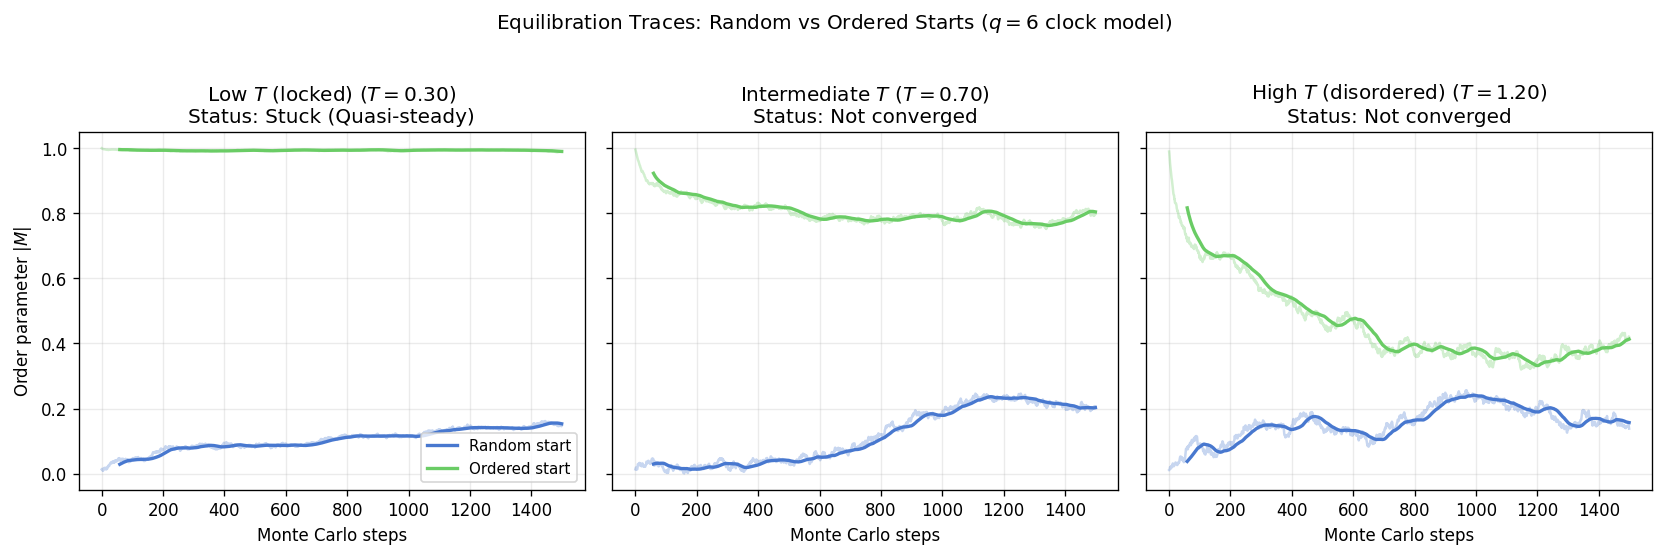

In [4]:
diagnostic_temps = [0.3, 0.7, 1.2]
diagnostic_titles = ['Low $T$ (locked)', 'Intermediate $T$', 'High $T$ (disordered)']
diagnostic_steps = 1500

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, t, title in zip(axes, diagnostic_temps, diagnostic_titles):
    sim_r = ClockSimulation(size=32, temp=t, q=Q_DEFAULT, update='checkerboard', init_state='random', seed=42)
    sim_o = ClockSimulation(size=32, temp=t, q=Q_DEFAULT, update='checkerboard', init_state='ordered', seed=42)

    m_r_list, _ = sim_r.run(n_steps=diagnostic_steps)
    m_o_list, _ = sim_o.run(n_steps=diagnostic_steps)

    m_r = np.asarray(m_r_list, dtype=float)
    m_o = np.asarray(m_o_list, dtype=float)

    tau_est = estimate_relaxation_time_two_start(m_r, m_o, smooth_window=60, dwell_window=60)

    smooth_r = np.convolve(m_r, np.ones(60) / 60, mode='valid')
    smooth_o = np.convolve(m_o, np.ones(60) / 60, mode='valid')
    is_stuck = _detect_quasi_steady_stuck(smooth_r, smooth_o, lattice_size=32)

    ax.plot(m_r, color=PALETTE['mag'], alpha=0.3)
    ax.plot(m_o, color=PALETTE['eng'], alpha=0.3)
    ax.plot(np.arange(59, diagnostic_steps), smooth_r, color=PALETTE['mag'], lw=2, label='Random start')
    ax.plot(np.arange(59, diagnostic_steps), smooth_o, color=PALETTE['eng'], lw=2, label='Ordered start')

    status_text = 'Converged'
    if tau_est < diagnostic_steps:
        ax.axvline(tau_est, color='0.2', ls='--', lw=1.5, label='Convergence achieved')
    else:
        if t < 0.5 and is_stuck:
            status_text = 'Stuck (Quasi-steady)'
        else:
            status_text = 'Not converged'

    ax.set_title(f'{title} ($T = {t:.2f}$)\nStatus: {status_text}')
    ax.set_xlabel('Monte Carlo steps')
    if ax is axes[0]:
        ax.set_ylabel(r'Order parameter $|M|$')
    ax.grid(alpha=0.25)

axes[0].legend(fontsize=9, loc='lower right')
fig.suptitle(f'Equilibration Traces: Random vs Ordered Starts ($q = {Q_DEFAULT}$ clock model)', y=1.02)
fig.tight_layout()
plt.show()

## Magnetization and Energy

The clock-model magnetization $|M|$ transitions from near-unity in the locked phase through a gradual decay in the quasi-ordered regime to near-zero in the disordered phase, with two inflection regions corresponding to the two crossovers. The energy per spin approaches the ground-state limit of $-2J$ as $T \to 0$ (the same ground-state energy as the XY model, since at $T = 0$ all spins align and the anisotropy term is maximized) and increases smoothly as thermal fluctuations excite spin-wave and vortex modes [[1]](#Bibliography) [[2]](#Bibliography).

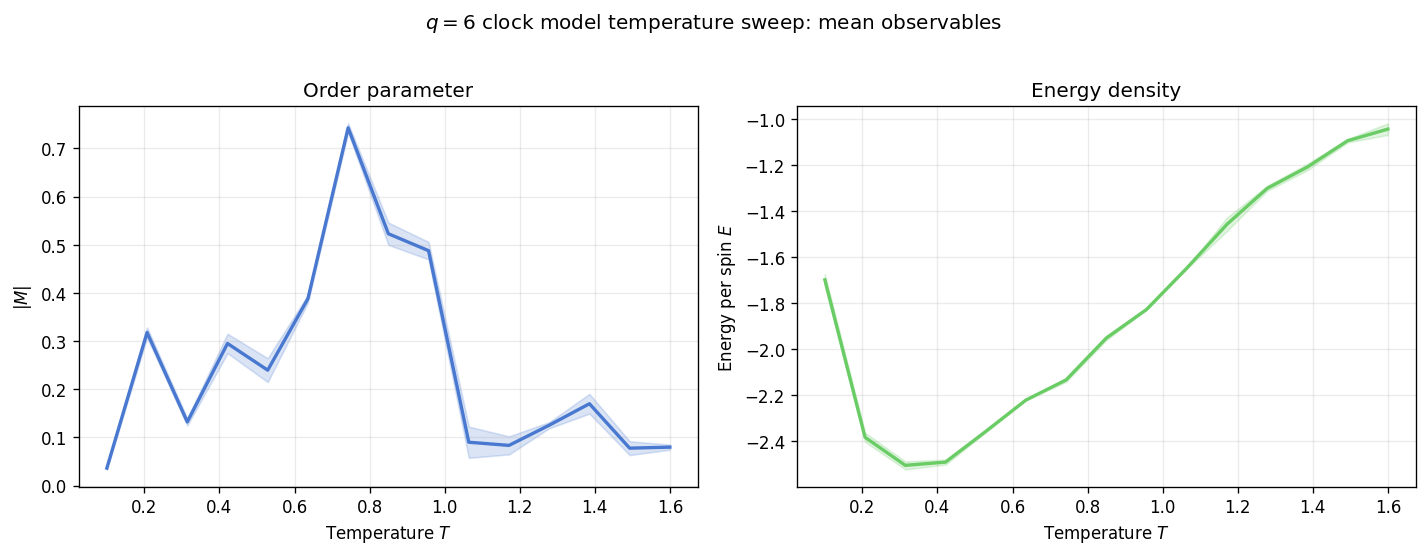

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(temperatures, avg_m_plot, color=PALETTE['mag'], lw=2)
axes[0].fill_between(temperatures, avg_m_ci_low_plot, avg_m_ci_high_plot, color=PALETTE['mag'], alpha=0.2)
axes[0].set_xlabel('Temperature $T$')
axes[0].set_ylabel(r'$|M|$')
axes[0].set_title('Order parameter')
axes[0].grid(alpha=0.25)

axes[1].plot(temperatures, avg_e_plot, color=PALETTE['eng'], lw=2)
axes[1].fill_between(temperatures, avg_e_ci_low_plot, avg_e_ci_high_plot, color=PALETTE['eng'], alpha=0.2)
axes[1].set_xlabel('Temperature $T$')
axes[1].set_ylabel(r'Energy per spin $E$')
axes[1].set_title('Energy density')
axes[1].grid(alpha=0.25)

fig.suptitle(f'$q = {Q_DEFAULT}$ clock model temperature sweep: mean observables', y=1.02)
fig.tight_layout()
plt.show()

## Susceptibility and Specific Heat

The susceptibility $\chi$ and specific heat $C_v$ for the $q = 6$ clock model can show two distinct humps corresponding to the two BKT-like crossovers, although finite-size effects and the smoothness of the BKT mechanism often cause these features to merge into a single broadened peak at small lattice sizes. The lower-temperature feature reflects the discrete locking transition where spins commit to their nearest clock axis, while the upper feature corresponds to vortex unbinding [[1]](#Bibliography) [[2]](#Bibliography).

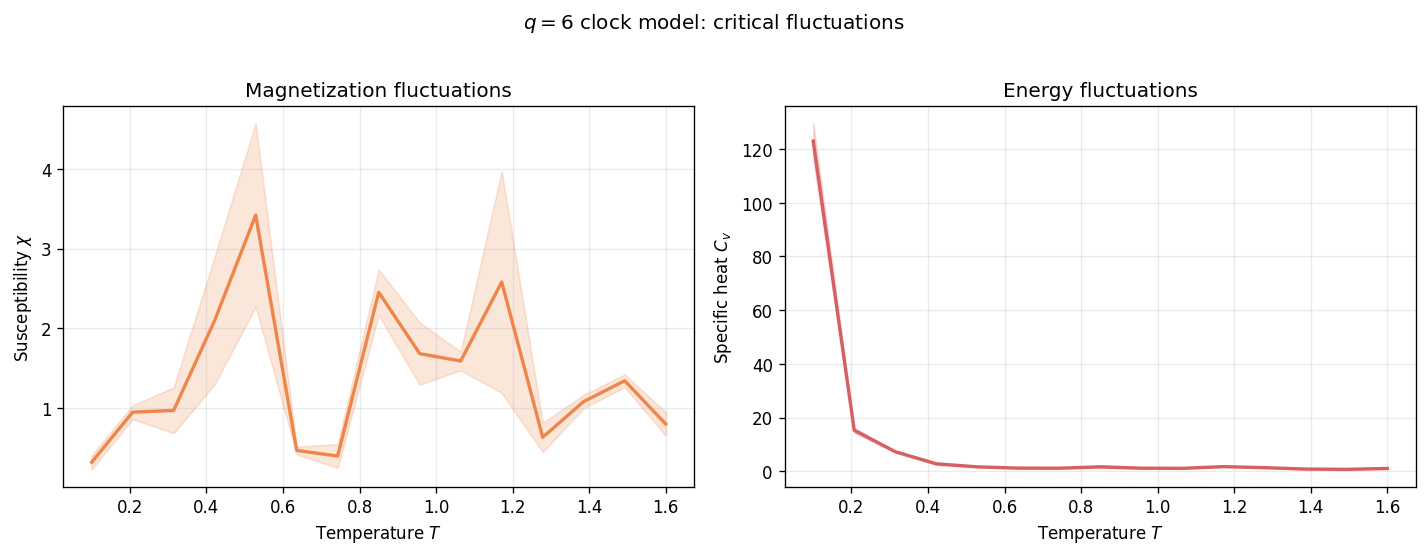

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(temperatures, susc_plot, color=PALETTE['chi'], lw=2)
axes[0].fill_between(temperatures, susc_ci_low_plot, susc_ci_high_plot, color=PALETTE['chi'], alpha=0.2)
axes[0].set_xlabel('Temperature $T$')
axes[0].set_ylabel(r'Susceptibility $\chi$')
axes[0].set_title('Magnetization fluctuations')
axes[0].grid(alpha=0.25)

axes[1].plot(temperatures, spec_h_plot, color=PALETTE['cv'], lw=2)
axes[1].fill_between(temperatures, spec_h_ci_low_plot, spec_h_ci_high_plot, color=PALETTE['cv'], alpha=0.2)
axes[1].set_xlabel('Temperature $T$')
axes[1].set_ylabel(r'Specific heat $C_v$')
axes[1].set_title('Energy fluctuations')
axes[1].grid(alpha=0.25)

fig.suptitle(f'$q = {Q_DEFAULT}$ clock model: critical fluctuations', y=1.02)
fig.tight_layout()
plt.show()

## Entropy

The relative entropy is reconstructed by thermodynamic integration of $C_v(T)/T$ from the highest sampled temperature downward. For the $q$-state clock model, the entropy at infinite temperature approaches $\ln q$ per site. At low temperature the entropy is reduced by the discrete symmetry breaking; the residual configurational freedom comes from vibrational (spin-wave) excitations around the chosen clock axis. Comparing the low-temperature plateau with the $\ln q$ limit gives a measure of how much entropy the locking transition has removed.

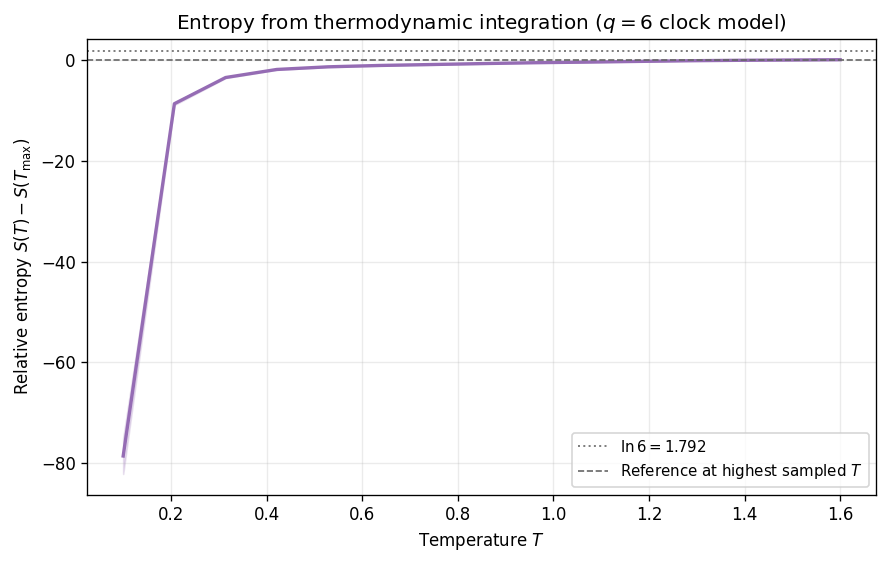

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(temperatures, entropy_plot, color=PALETTE['entropy'], lw=2)
ax.fill_between(temperatures, entropy_ci_low_plot, entropy_ci_high_plot, color=PALETTE['entropy'], alpha=0.2)
ax.axhline(S_REF, color='0.5', ls=':', lw=1.2, label=rf'$\ln {Q_DEFAULT} = {S_REF:.3f}$')
ax.axhline(0.0, color='0.4', ls='--', lw=1.0, label=r'Reference at highest sampled $T$')
ax.set_xlabel('Temperature $T$')
ax.set_ylabel(r'Relative entropy $S(T) - S(T_{\max})$')
ax.set_title(f'Entropy from thermodynamic integration ($q = {Q_DEFAULT}$ clock model)')
ax.grid(alpha=0.25)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## Critical Slowing Down

The integrated autocorrelation time $\tau_{\mathrm{int}}$ rises near both crossover temperatures. Near the upper crossover the slowing mechanism is the same as in the XY model: large-scale vortex fluctuations become hard to decorrelate with local updates. Near the lower crossover the slowing is caused by domain walls between regions locked to different clock axes. The effective sample size $N_{\mathrm{eff}} \sim N_{\mathrm{meas}} / (2\tau_{\mathrm{int}})$ drops accordingly, and flagged points indicate temperatures where the autocorrelation estimate is undefined or unreliable [[3]](#Bibliography) [[4]](#Bibliography).

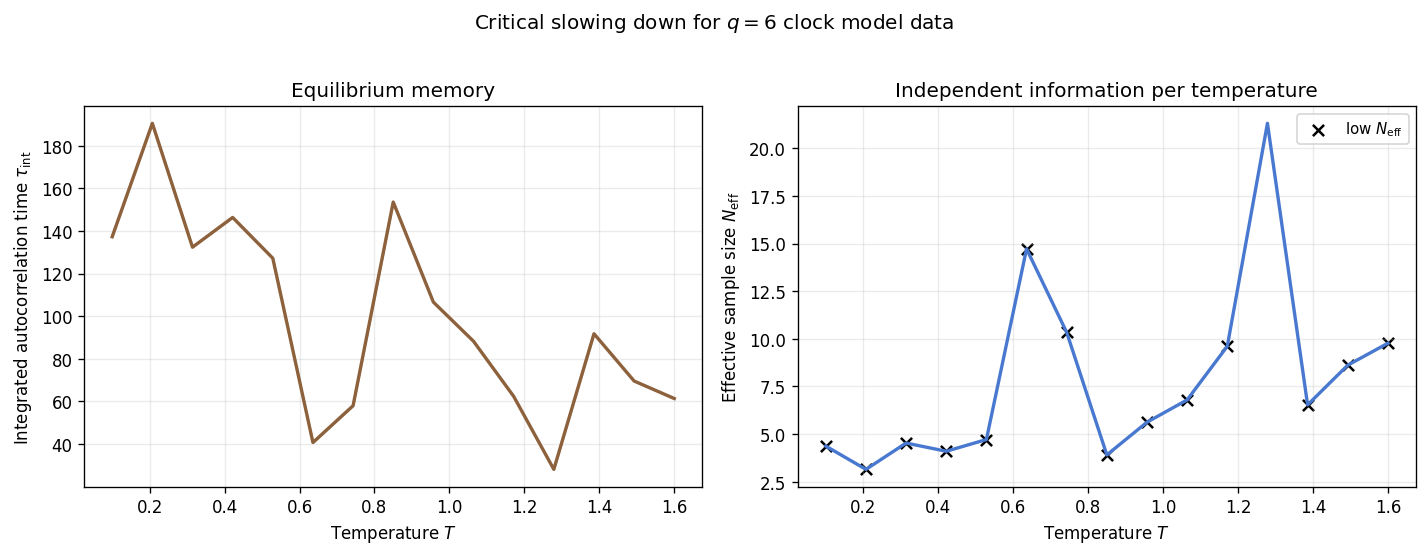

In [8]:
flagged_tau = (undefined_autocorr_flag > 0) | (tau_interval_unstable_flag > 0)
flagged_neff = low_effective_sample_flag > 0

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(temperatures, tau_int, color=PALETTE['tau'], lw=2)
axes[0].fill_between(temperatures, tau_int_ci_low, tau_int_ci_high, color=PALETTE['tau'], alpha=0.2)
if np.any(flagged_tau):
    axes[0].scatter(
        temperatures[flagged_tau],
        tau_int[flagged_tau],
        color='black',
        marker='x',
        s=45,
        label='flagged point',
    )
axes[0].set_xlabel('Temperature $T$')
axes[0].set_ylabel(r'Integrated autocorrelation time $\tau_{\mathrm{int}}$')
axes[0].set_title('Equilibrium memory')
axes[0].grid(alpha=0.25)
if np.any(flagged_tau):
    axes[0].legend(fontsize=9)

axes[1].plot(temperatures, avg_m_n_eff, color=PALETTE['mag'], lw=2)
if np.any(flagged_neff):
    axes[1].scatter(
        temperatures[flagged_neff],
        avg_m_n_eff[flagged_neff],
        color='black',
        marker='x',
        s=45,
        label=r'low $N_{\mathrm{eff}}$',
    )
axes[1].set_xlabel('Temperature $T$')
axes[1].set_ylabel(r'Effective sample size $N_{\mathrm{eff}}$')
axes[1].set_title('Independent information per temperature')
axes[1].grid(alpha=0.25)
if np.any(flagged_neff):
    axes[1].legend(fontsize=9)

fig.suptitle(f'Critical slowing down for $q = {Q_DEFAULT}$ clock model data', y=1.02)
fig.tight_layout()
plt.show()

## Autocorrelation Function at Three Temperatures

The autocorrelation function $\rho_M(\tau)$ reveals how the Markov chain decorrelates its magnetization signal at different temperatures. In the locked phase the system sits in a deep minimum and the decorrelation is modest (relatively few active modes). Near the intermediate crossover, decorrelation slows as the system fluctuates between orientational domains. In the disordered phase the chain is relatively free-moving and $\rho_M$ decays quickly [[3]](#Bibliography) [[4]](#Bibliography).

convergence_equilibrate: detected quasi-steady stuck state before max_steps=9000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=9000; stopping early without convergence.
convergence_equilibrate: detected quasi-steady stuck state before max_steps=9000; stopping early without convergence.


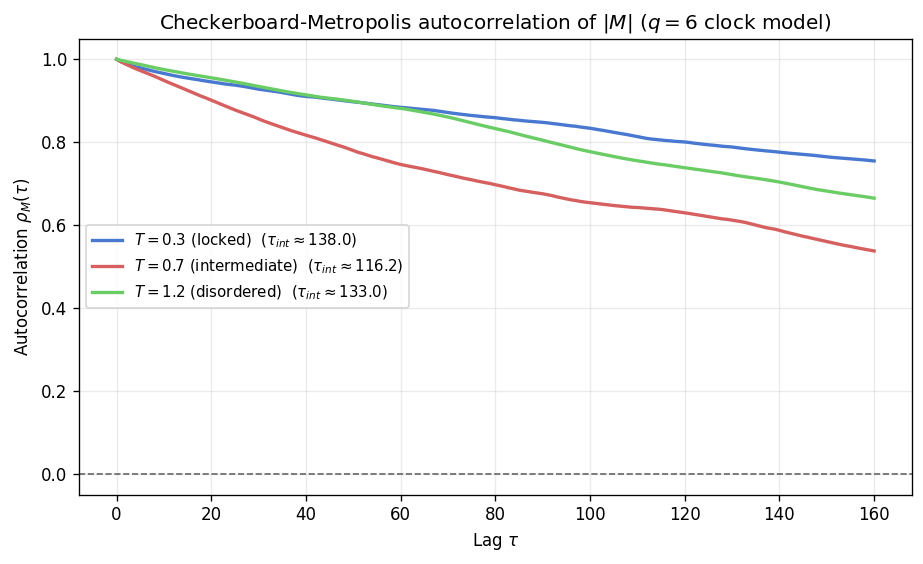

In [9]:
autocorr_temperatures = [0.3, 0.7, 1.2]
autocorr_labels = ['$T = 0.3$ (locked)', '$T = 0.7$ (intermediate)', '$T = 1.2$ (disordered)']
autocorr_colors = ['#4878CF', '#D65F5F', '#6ACC65']

fig, ax = plt.subplots(figsize=(7.8, 4.8))

for idx, (temp, label, color) in enumerate(zip(autocorr_temperatures, autocorr_labels, autocorr_colors)):
    sim_random = ClockSimulation(
        size=40,
        temp=float(temp),
        q=Q_DEFAULT,
        update='checkerboard',
        init_state='random',
        seed=6_000 + idx,
    )
    sim_ordered = ClockSimulation(
        size=40,
        temp=float(temp),
        q=Q_DEFAULT,
        update='checkerboard',
        init_state='ordered',
        seed=6_000 + idx,
    )
    convergence_equilibrate(
        sim_random,
        sim_ordered,
        chunk_size=120,
        max_steps=9_000,
    )
    mags, _ = sim_random.run(n_steps=1_600)
    mags_arr = np.asarray(mags, dtype=float)
    try:
        corr, tau_here = calculate_autocorr(time_series=mags_arr, max_lag=160)
    except ZeroVarianceAutocorrelationError:
        corr = np.array([np.nan])
        tau_here = float('nan')
    lags = np.arange(corr.size)
    ax.plot(lags, corr, lw=2, color=color, label=f'{label}  ($\\tau_{{int}} \\approx {tau_here:.1f}$)')

ax.axhline(0.0, color='0.4', ls='--', lw=1.0)
ax.set_xlabel(r'Lag $\tau$')
ax.set_ylabel(r'Autocorrelation $\rho_M(\tau)$')
ax.set_title(rf'Checkerboard-Metropolis autocorrelation of $|M|$ ($q = {Q_DEFAULT}$ clock model)')
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.25)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## Synthesis

The full temperature sweep reveals the three-regime structure of the $q = 6$ clock model. Below the lower crossover, the system is locked into a single clock direction with high magnetization and low entropy. In the intermediate quasi-ordered phase, correlations decay algebraically and the magnetization softens without vanishing. Above the upper crossover, the system is fully disordered. The susceptibility, specific heat, and autocorrelation time all reflect these two crossover regions, although finite-size rounding may blur the double-peak structure into a single broad feature on small lattices. Comparing these curves with the XY Temperature Sweep notebook illustrates how discrete symmetry breaking modifies the BKT crossover and introduces the lower locking transition that has no analog in the continuous-symmetry case.

## Bibliography

[[1]](#Bibliography) C. M. Lapilli, P. Pfeifer, and C. Wexler, "Universality away from critical points in two-dimensional phase transitions," *Physical Review Letters* 96, 140603 (2006). [arXiv:cond-mat/0603308](https://arxiv.org/abs/cond-mat/0603308)

[[2]](#Bibliography) S. K. Baek and P. Minnhagen, "Non-Kosterlitz-Thouless transitions for the q-state clock models," *Physical Review E* 82, 031102 (2010). [arXiv:1005.3maximum](https://arxiv.org/abs/1005.3maximum) [APS](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.82.031102)

[[3]](#Bibliography) A. D. Sokal, "Monte Carlo Methods in Statistical Mechanics: Foundations and New Algorithms," lecture notes (1989), reprinted in *Functional Integration: Basics and Applications* (1997). [Springer Link](https://link.springer.com/chapter/10.1007/978-1-4899-0319-8_6)

[[4]](#Bibliography) M. E. J. Newman and G. T. Barkema, *Monte Carlo Methods in Statistical Physics*, Oxford University Press (1999). [Lecture notes summary](https://arxiv.org/abs/0905.1629)